#### Chart: Examples of Neural Network Hypotheses


[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week14/chart_examples_of_neural_network_hypotheses.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week14/chart_examples_of_neural_network_hypotheses.ipynb)



NN Sample Hypothesis 1


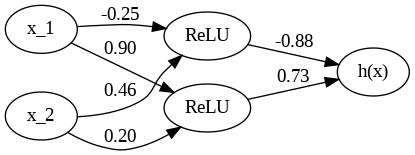

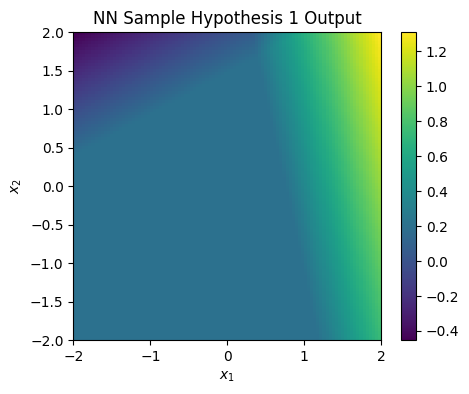

NN Sample Hypothesis 2


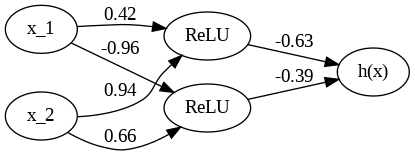

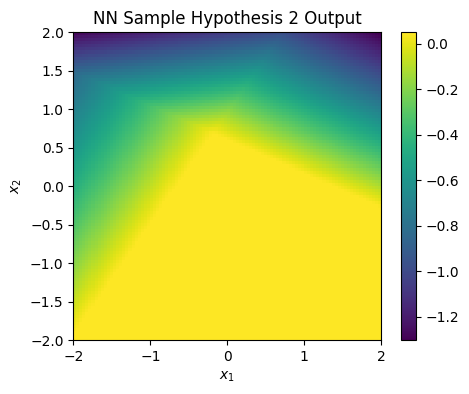

NN Sample Hypothesis 3


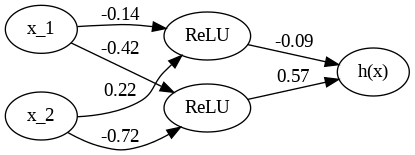

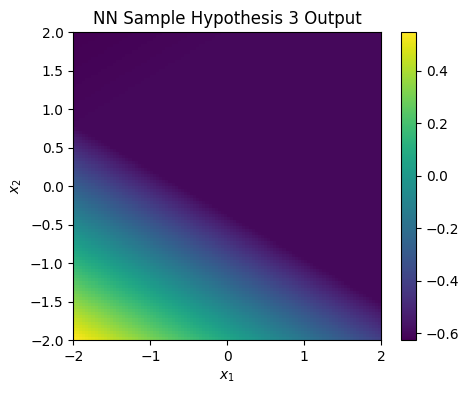

NN Sample Hypothesis 4


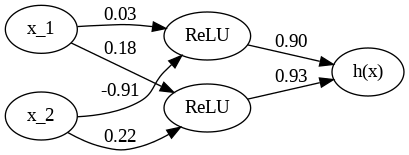

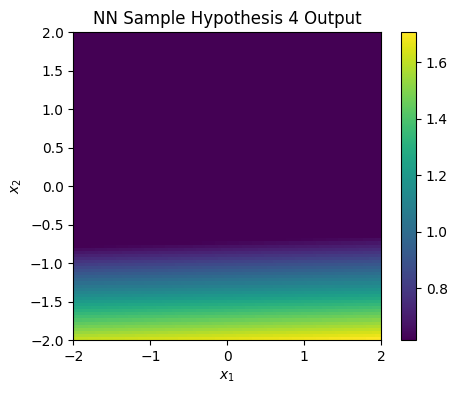

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import graphviz
from IPython.display import display, Image

# Set seed for reproducibility
np.random.seed(42)

# Define a grid for 2D inputs
res = 100
x1 = np.linspace(-2, 2, res)
x2 = np.linspace(-2, 2, res)
X1, X2 = np.meshgrid(x1, x2)
X_grid = np.vstack([X1.ravel(), X2.ravel()]).T

def relu(x):
    return np.maximum(0, x)

def get_nn_diagram(W1, b1, W2, b2):
    dot = graphviz.Digraph(graph_attr={'rankdir':'LR', 'size': '5,5'})
    hidden_size = W1.shape[1]
    # Nodes
    dot.node('x1', 'x_1')
    dot.node('x2', 'x_2')
    for j in range(hidden_size):
        dot.node(f'h{j}', f'ReLU')
    dot.node('y', 'h(x)')
    # Edges
    for i in range(2):
        for j in range(hidden_size):
            label = f'{W1[i,j]:.2f}'
            dot.edge(f'x{i+1}', f'h{j}', label=label)
    for j in range(hidden_size):
        label = f'{W2[j,0]:.2f}'
        dot.edge(f'h{j}', 'y', label=label)
    return dot

def random_nn_hypothesis(X, hidden_size=2):
    W1 = np.random.uniform(-1, 1, (2, hidden_size))
    b1 = np.random.uniform(-1, 1, hidden_size)
    W2 = np.random.uniform(-1, 1, (hidden_size, 1))
    b2 = np.random.uniform(-1, 1, 1)

    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)
    y = np.dot(a1, W2) + b2
    return y.reshape(res, res), (W1, b1, W2, b2)

# Interleave Diagrams and Heatmaps
for i in range(4):
    Z, weights = random_nn_hypothesis(X_grid, hidden_size=2)

    print(f"NN Sample Hypothesis {i+1}")
    dot = get_nn_diagram(*weights)
    # Render the dot graph as a PNG image
    display(Image(dot.pipe(format='png')))

    plt.figure(figsize=(5, 4))
    im = plt.imshow(Z, extent=[-2, 2, -2, 2], origin='lower', cmap='viridis')
    plt.title(f'NN Sample Hypothesis {i+1} Output')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.colorbar(im)
    plt.show()